In [1]:
import pandas as pd
from chainconsumer import Chain, ChainConsumer, Truth
import numpy as np

from astropy import units as u
from odisseo.units import CodeUnits

from matplotlib.patches import Rectangle

Parameter $M_{plummer}$ in chain Simulated Feedback is not constrained


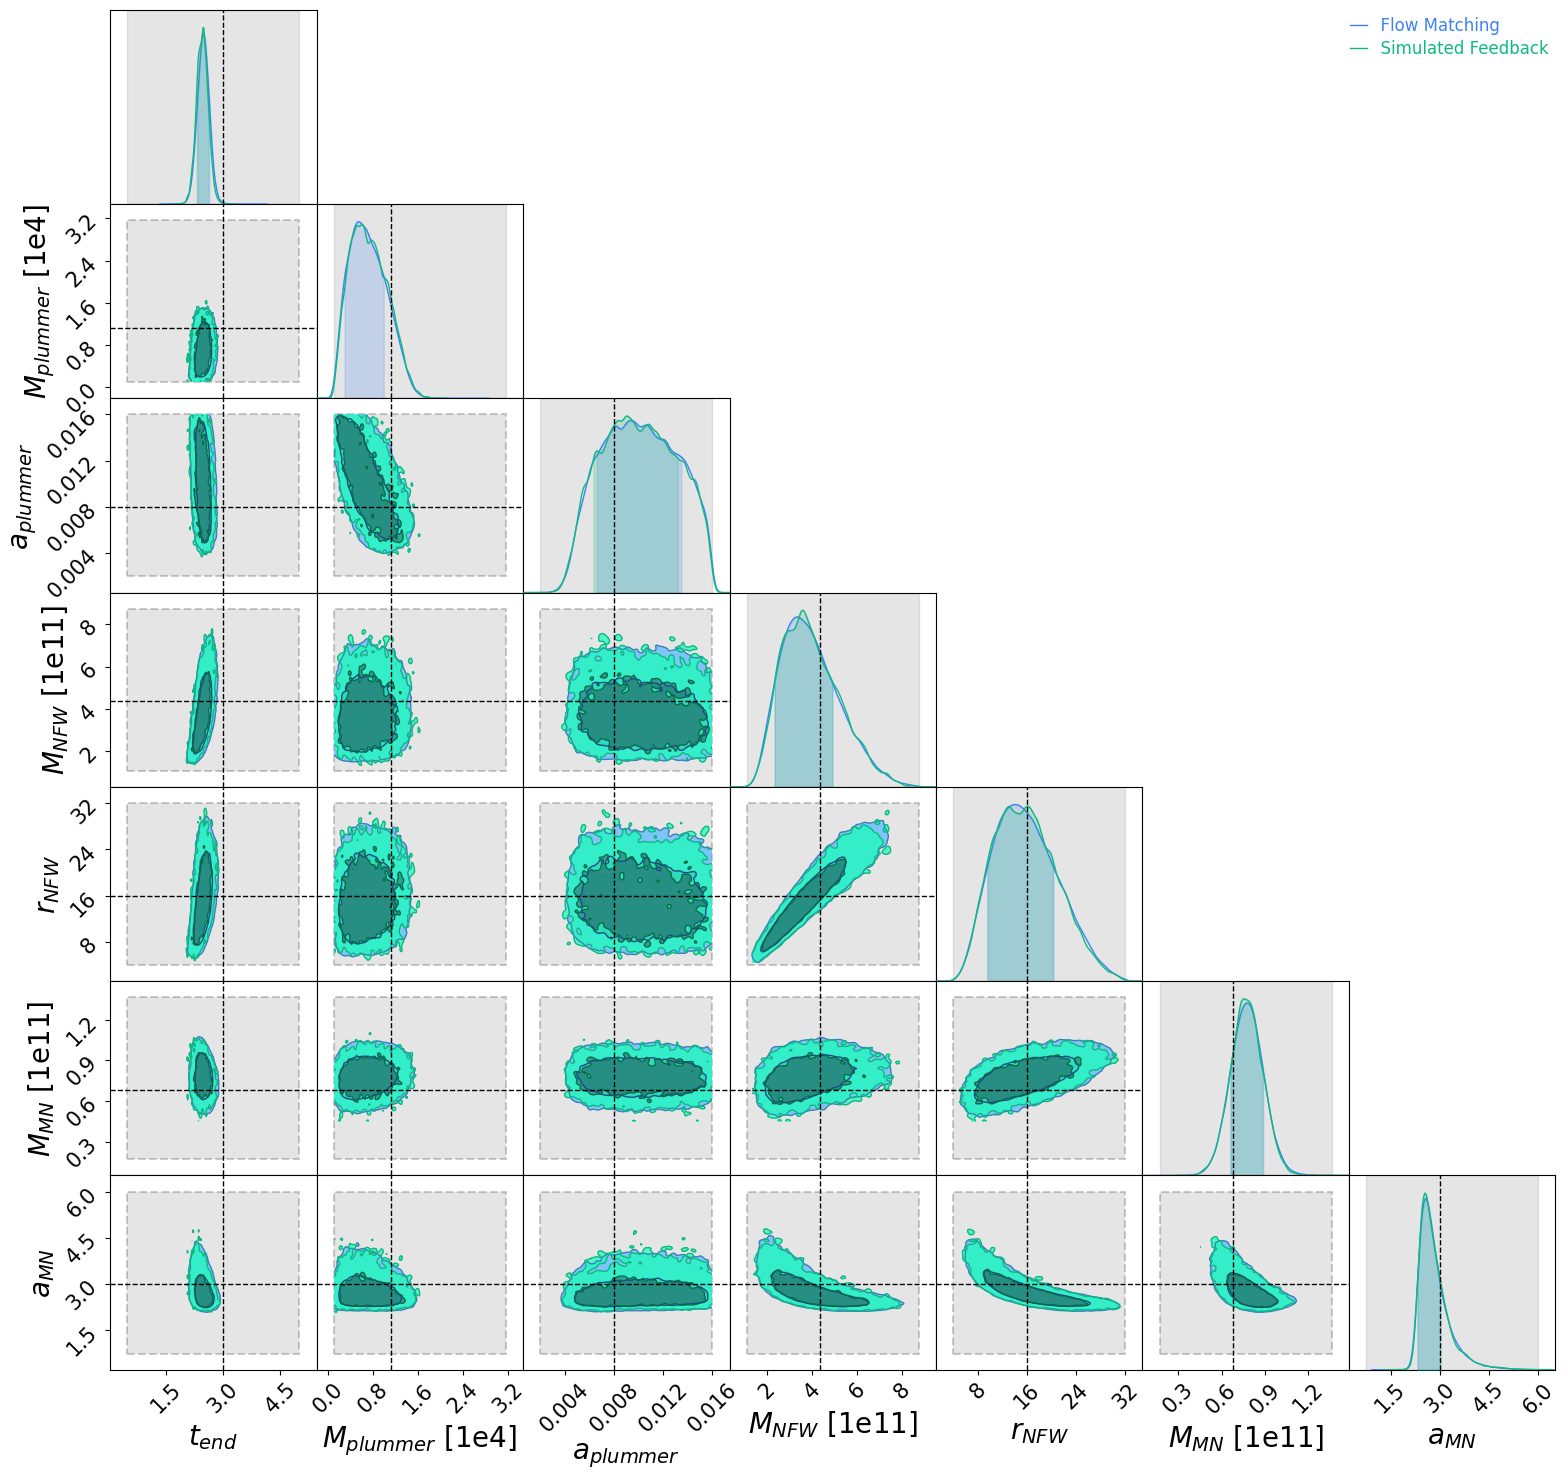

In [5]:
data_FM = np.load('./logs/Odisseo_OT_AllParameters/pictures/true_observation_prediction.npz')['predicted_theta']

data_SimFeedback = np.load('./logs/OdisseoSimulatorOT_AllParameters/pictures/true_observation_prediction.npz')['predicted_theta']


true_theta = np.load('./logs/OdisseoSimulatorOT_AllParameters/pictures/true_observation_prediction.npz')['true_theta']
labels = ['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$']

df_FM = pd.DataFrame(data_FM, columns=labels)
df_FM = df_FM.astype(float)

df_SimFeedback = pd.DataFrame(data_SimFeedback, columns=labels)
df_SimFeedback = df_SimFeedback.astype(float)

code_length = 10 * u.kpc
code_mass = 1e4 * u.Msun
G = 1
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  


prior_bounds = {
    labels[0]: [0.5, 5.0],                    # t_end: 0.5 to 5 Gyr
    labels[1]: [10**3, 10**4.5],              # Plummer Mtot: 10^3 to 10^4.5 Msun
    labels[2]: [8.0 * 1e-3 * 0.25, 8.0 * 1e-3 * 2.0],  # Plummer a: 1/4 to 2x true (kpc)
    labels[3]: [4.3683325e11 * 0.25, 4.3683325e11 * 2.0],  # NFW Mvir: 1/4 to 2x true
    labels[4]: [16.0 * 0.25, 16.0 * 2.0],    # NFW r_s: 1/4 to 2x true (kpc)
    labels[5]: [68_193_902_782.346756 * 0.25, 68_193_902_782.346756 * 2.0],  # MN M: 1/4 to 2x true
    labels[6]: [3.0 * 0.25, 3.0 * 2.0],      # MN a: 1/4 to 2x true (kpc)
}  # Shape: (7, 2) for [min, max] bound

c = ChainConsumer()
c.add_chain(Chain(samples=df_FM, name="Flow Matching", ), )
c.add_chain(Chain(samples=df_SimFeedback, name="Simulated Feedback", ), )
c.add_truth(Truth(location={
        '$t_{end}$': true_theta[0] * code_units.code_time.to(u.Gyr),
        '$M_{plummer}$': true_theta[1] * code_units.code_mass.to(u.Msun),
        '$a_{plummer}$': true_theta[2] * code_units.code_length.to(u.kpc),
        '$M_{NFW}$': true_theta[3] * code_units.code_mass.to(u.Msun),
        '$r_{NFW}$': true_theta[4] * code_units.code_length.to(u.kpc),
        '$M_{MN}$': true_theta[5] * code_units.code_mass.to(u.Msun),
        '$a_{MN}$': true_theta[6] * code_units.code_length.to(u.kpc),
}))


fig = c.plotter.plot()   


# === Overlay prior boxes AND set limits ===
axes = fig.axes
n_params = len(df_FM.columns)

# Calculate expanded limits (10% padding outside prior bounds)
expanded_bounds = {}
for param in labels:
    low, high = prior_bounds[param]
    range_width = high - low
    padding = range_width * 0.1  # 10% padding
    expanded_bounds[param] = [low - padding, high + padding]

for i, p1 in enumerate(df_FM.columns):
    for j, p2 in enumerate(df_FM.columns):
        ax = axes[i * n_params + j]

        if i == j:
            # 1D marginal → shade prior range and set limits
            low, high = prior_bounds[p1]
            ax.axvspan(low, high, color="gray", alpha=0.2)
            # Set x-limits to expanded bounds
            ax.set_xlim(expanded_bounds[p1])
            
        elif i > j:
            # 2D subplot → add filled rectangle and set limits
            xlow, xhigh = prior_bounds[p2]
            ylow, yhigh = prior_bounds[p1]
            rect = Rectangle((xlow, ylow), xhigh - xlow, yhigh - ylow,
                             linewidth=1.5, edgecolor="black",
                             facecolor="gray", alpha=0.2, linestyle="--")
            ax.add_patch(rect)
            # Set both x and y limits to expanded bounds
            ax.set_xlim(expanded_bounds[p2])
            ax.set_ylim(expanded_bounds[p1])

for ax in fig.get_axes():
    ax.tick_params(axis="both", which="major", labelsize=15)
    ax.tick_params(axis="both", which="minor", labelsize=20)
    ax.xaxis.label.set_size(20)
    ax.yaxis.label.set_size(20)
    ax.title.set_size(20)

Parameter $a_{plummer}$ in chain Flow Matching is not constrained
Parameter $r_{NFW}$ in chain Simulated Feedback is not constrained


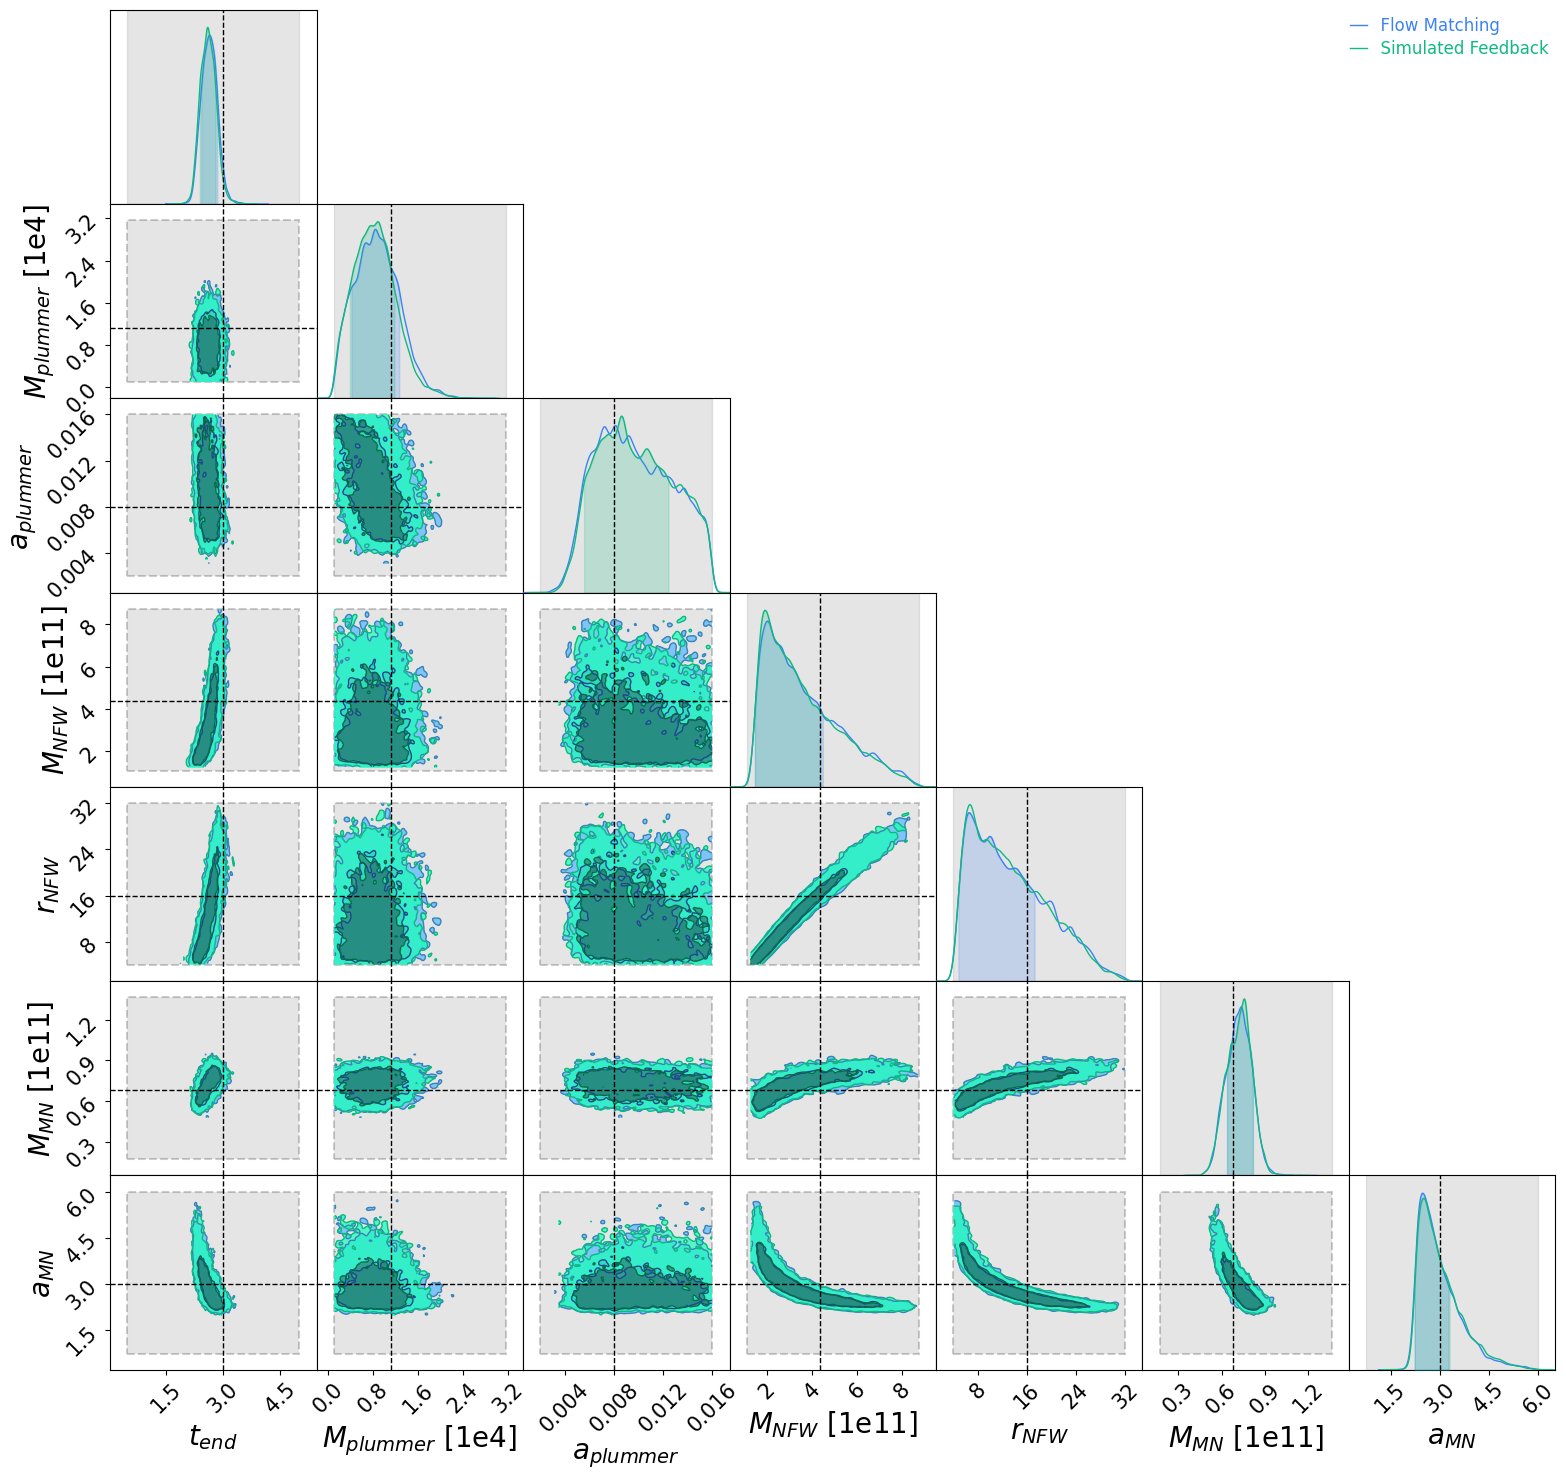

In [7]:
data_FM = np.load('./logs/OdisseoSetTransformerLarge_OT_AllParameters/pictures/true_observation_prediction.npz')['predicted_theta']

data_SimFeedback = np.load('./logs/OdisseoSimulatorSetTransformerLarge_OT_AllParameters/pictures/true_observation_prediction.npz')['predicted_theta']


true_theta = np.load('./logs/OdisseoSimulatorOT_AllParameters/pictures/true_observation_prediction.npz')['true_theta']
labels = ['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$']

df_FM = pd.DataFrame(data_FM, columns=labels)
df_FM = df_FM.astype(float)

df_SimFeedback = pd.DataFrame(data_SimFeedback, columns=labels)
df_SimFeedback = df_SimFeedback.astype(float)


code_length = 10 * u.kpc
code_mass = 1e4 * u.Msun
G = 1
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  

c = ChainConsumer()
c.add_chain(Chain(samples=df_FM, name="Flow Matching", ), )
c.add_chain(Chain(samples=df_SimFeedback, name="Simulated Feedback", ), )

c.add_truth(Truth(location={
        '$t_{end}$': true_theta[0] * code_units.code_time.to(u.Gyr),
        '$M_{plummer}$': true_theta[1] * code_units.code_mass.to(u.Msun),
        '$a_{plummer}$': true_theta[2] * code_units.code_length.to(u.kpc),
        '$M_{NFW}$': true_theta[3] * code_units.code_mass.to(u.Msun),
        '$r_{NFW}$': true_theta[4] * code_units.code_length.to(u.kpc),
        '$M_{MN}$': true_theta[5] * code_units.code_mass.to(u.Msun),
        '$a_{MN}$': true_theta[6] * code_units.code_length.to(u.kpc),
}))
fig = c.plotter.plot()   


# === Overlay prior boxes AND set limits ===
axes = fig.axes
n_params = len(df_FM.columns)

# Calculate expanded limits (10% padding outside prior bounds)
expanded_bounds = {}
for param in labels:
    low, high = prior_bounds[param]
    range_width = high - low
    padding = range_width * 0.1  # 10% padding
    expanded_bounds[param] = [low - padding, high + padding]

for i, p1 in enumerate(df_FM.columns):
    for j, p2 in enumerate(df_FM.columns):
        ax = axes[i * n_params + j]

        if i == j:
            # 1D marginal → shade prior range and set limits
            low, high = prior_bounds[p1]
            ax.axvspan(low, high, color="gray", alpha=0.2)
            # Set x-limits to expanded bounds
            ax.set_xlim(expanded_bounds[p1])
            
        elif i > j:
            # 2D subplot → add filled rectangle and set limits
            xlow, xhigh = prior_bounds[p2]
            ylow, yhigh = prior_bounds[p1]
            rect = Rectangle((xlow, ylow), xhigh - xlow, yhigh - ylow,
                             linewidth=1.5, edgecolor="black",
                             facecolor="gray", alpha=0.2, linestyle="--")
            ax.add_patch(rect)
            # Set both x and y limits to expanded bounds
            ax.set_xlim(expanded_bounds[p2])
            ax.set_ylim(expanded_bounds[p1])

for ax in fig.get_axes():
    ax.tick_params(axis="both", which="major", labelsize=15)
    ax.tick_params(axis="both", which="minor", labelsize=20)
    ax.xaxis.label.set_size(20)
    ax.yaxis.label.set_size(20)
    ax.title.set_size(20)